In [2]:
import torch
import numpy as np
import sys
import os
from pathlib import Path
import pyvista as pv
import scipy.sparse as sp
import pyamg

if Path.cwd().as_posix().endswith('/collocation_01'):
    os.chdir('../..')
from gnp import GeometryEstimator

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
pv.set_jupyter_backend("static")

In [3]:
def get_data(data_name, noise_level=0.0, noise_ratio=0.0):
    data_path = os.path.join('example_data', data_name)
    data = {}
    for file in os.listdir(data_path):
        if file.endswith('.npy'):
            data[file[:-4]] = torch.from_numpy(np.load(os.path.join(data_path, file))).to(device)
    if noise_level > 0.0 and noise_ratio > 0.0:
        xyz = data['xyz']
        noise_inds = torch.randperm(xyz.shape[0])[:int(noise_ratio*xyz.shape[0])]
        noise = torch.randn_like(xyz[noise_inds]) * noise_level
        xyz[noise_inds] += noise
        data['xyz'] = xyz
    return data

In [4]:
data = get_data('radial')
import os

In [5]:
estimator = GeometryEstimator(pcd=data['xyz'], 
                              orientation=data['normals'], 
                              model='clean_30k',
                              device=device)

/Users/ellakim/Downloads/geo_neural_op-main/gnp/config.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location='cpu'))

In [6]:
stiffness = estimator.stiffness_matrix_gmls(drop_ratio=0.1)

782it [10:55,  1.19it/s]


In [7]:
ls_stiffness = stiffness.T @ stiffness

In [14]:
ml = pyamg.smoothed_aggregation_solver(ls_stiffness,
                                       symmetry='symmetric',
                                       max_levels=5,
                                       coarse_solver='pinv',
                                       strength='symmetric',
                                       max_coarse=10)
print(ml)
precondtioner = ml.aspreconditioner(cycle='W')

MultilevelSolver
Number of Levels:     4
Operator Complexity:   1.001
Grid Complexity:       1.006
Coarse Solver:        'pinv'
  level   unknowns     nonzeros
     0       90000     10343872 [99.90%]
     1         500        10248 [0.10%]
     2          15          189 [0.00%]
     3           1            1 [0.00%]



In [15]:
collocation_mask = estimator.data['stiffness_mask'].cpu().numpy()

In [16]:
solution = data['solutions'][:, 2].cpu().numpy()
source = data['sources'][:, 2].cpu().numpy()

In [17]:
residuals = []
def report_callback(sol_vec):
    source_error = (np.linalg.norm((stiffness @ sol_vec - source)) 
                    / np.linalg.norm(source))
    sol_residual = np.linalg.norm(sol_vec - solution[collocation_mask]) / np.linalg.norm(solution[collocation_mask])
    residuals.append(sol_residual)
    if len(residuals) % 10 == 0:
        print(f'Iteration {len(residuals)} Solution Error: {sol_residual:.3e}, Source Error: {source_error:.3e}')

dtype = ls_stiffness.dtype
B = np.ones((ls_stiffness.shape[0], 1), dtype=dtype)

output = sp.linalg.lgmres(A=ls_stiffness,
                          b=B,
                          M=precondtioner,
                          rtol=1e-5,
                          atol=0,
                          maxiter=100,
                          callback=report_callback)
pred = output[0]
pred -= pred.mean()

error = np.linalg.norm(pred - solution[collocation_mask]) / np.linalg.norm(solution[collocation_mask])
print(f'Final Solution Error: {error:.3e}')

Iteration 10 Solution Error: 2.073e+00, Source Error: 2.794e+00
Iteration 20 Solution Error: 2.569e+00, Source Error: 1.553e+00
Iteration 30 Solution Error: 2.614e+00, Source Error: 1.462e+00
Iteration 40 Solution Error: 5.403e+02, Source Error: 8.334e+02
Iteration 50 Solution Error: 2.235e+05, Source Error: 5.160e+05
Iteration 60 Solution Error: 7.152e+04, Source Error: 6.886e+04
Iteration 70 Solution Error: 6.804e+04, Source Error: 6.306e+04
Iteration 80 Solution Error: 1.129e+05, Source Error: 3.161e+05
Iteration 90 Solution Error: 1.042e+08, Source Error: 4.602e+08
Iteration 100 Solution Error: 5.451e+10, Source Error: 1.759e+11
Final Solution Error: 3.732e+11


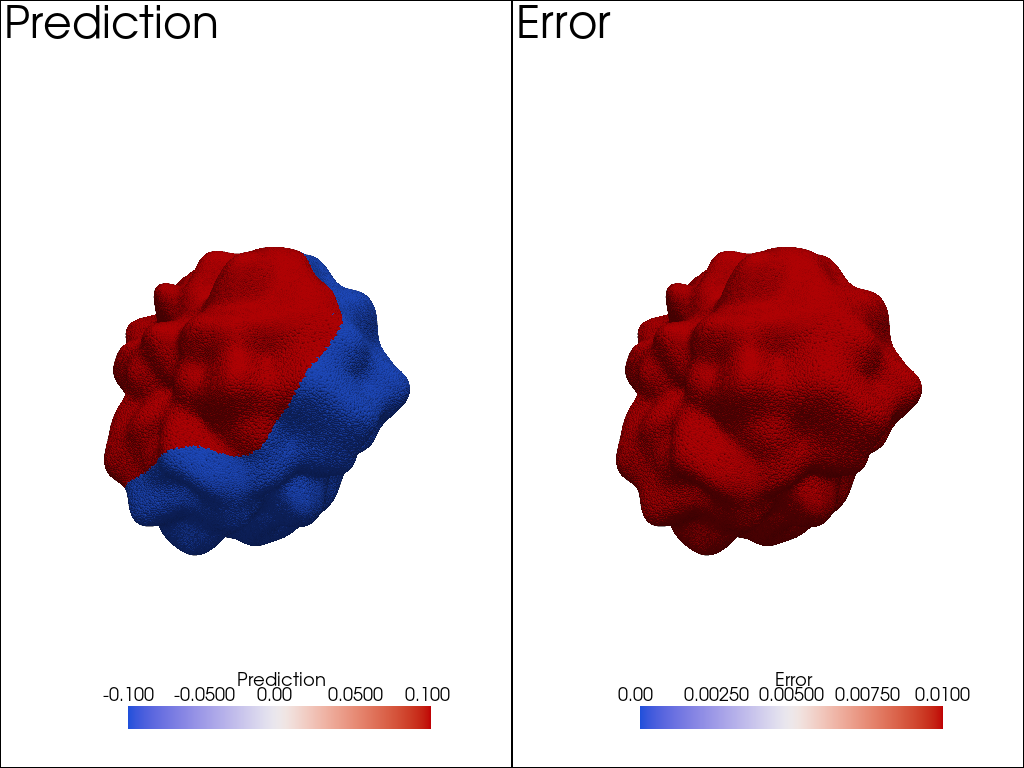

In [18]:
pv_data = pv.PolyData(data['xyz'].cpu().numpy()[collocation_mask])
pv_data['Prediction'] = pred
pv_data['Error'] = np.abs(pred - solution[collocation_mask])

camera_position = [(-5.540426247912693, 1.6662489557744946, -3.5168265303256296),
                   (-0.05816924426784502, 0.08683893634845968, 0.05411275262662977),
                   (0.16073463828406648, 0.9700217471130059, 0.1822695426655861)]
scalar_bar_args = dict(position_x=0.25)

pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text('Prediction', font_size=18)
pl.add_points(pv_data, 
              point_size=6,
              render_points_as_spheres=True,
              scalars='Prediction', 
              clim=[-0.1, 0.1],
              cmap='coolwarm',
              scalar_bar_args=scalar_bar_args)
pl.camera_position = camera_position
pl.camera.zoom(0.65)
pl.subplot(0, 1)
pl.add_text('Error', font_size=18)
pl.add_points(pv_data,
              point_size=6,
              render_points_as_spheres=True, 
              scalars='Error', 
              cmap='coolwarm', 
              clim=[0, 0.01],
              copy_mesh=True,
              scalar_bar_args=scalar_bar_args)
pl.camera_position = camera_position
pl.camera.zoom(0.65)
pl.show()